<a href="https://colab.research.google.com/github/B-Pearlraj/App-User-Behavior-Segmentation/blob/main/App_User_Behavior_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Load dataset
file_path = r"app_user_behavior_dataset.csv"

df = pd.read_csv(file_path)

In [ ]:
# Dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (50000, 25)


In [ ]:
# First 5 rows
display(df.head())

,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,...,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,...,20,Basic,9,5,2,NaN,0.31,55.79,1152,Referral
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,...,7,Free,8,3,3,3.0,0.87,82.39,1059,Email Campaign
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,...,33,Free,11,6,1,2.0,0.63,42.49,678,Google Ads
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,...,17,Basic,6,3,1,3.0,0.43,62.81,92,Organic
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,...,21,Basic,4,4,2,5.0,0.43,38.21,772,Email Campaign


In [ ]:
# Column information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        50000 non-null  int64  
 1   age                            50000 non-null  int64  
 2   gender                         50000 non-null  object 
 3   country                        50000 non-null  object 
 4   device_type                    50000 non-null  object 
 5   app_version                    50000 non-null  float64
 6   sessions_per_week              50000 non-null  int64  
 7   avg_session_duration_min       50000 non-null  float64
 8   daily_active_minutes           50000 non-null  float64
 9   feature_clicks_per_session     50000 non-null  int64  
 10  notifications_opened_per_week  50000 non-null  int64  
 11  in_app_search_count            50000 non-null  int64  
 12  pages_viewed_per_session       50000 non-null 

In [ ]:
# Statistical summary
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,50000.0,NaN,NaN,NaN,124999.5,14433.901067,100000.0,112499.75,124999.5,137499.25,149999.0
age,50000.0,NaN,NaN,NaN,38.51304,12.094948,18.0,28.0,39.0,49.0,59.0
gender,50000,3,Female,23994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,50000,7,India,22550,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,50000,3,Android,27315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
app_version,50000.0,NaN,NaN,NaN,1.476126,0.470158,1.0,1.1,1.2,2.0,2.1
sessions_per_week,50000.0,NaN,NaN,NaN,7.99968,2.829438,0.0,6.0,8.0,10.0,26.0
avg_session_duration_min,50000.0,NaN,NaN,NaN,13.149842,8.946944,0.06,6.57,11.24,17.57,91.4
daily_active_minutes,50000.0,NaN,NaN,NaN,45.164537,19.505118,5.0,31.65,45.21,58.44,129.13
feature_clicks_per_session,50000.0,NaN,NaN,NaN,12.01392,3.480289,1.0,10.0,12.0,14.0,28.0


In [ ]:
# Missing values
display(df.isnull().sum().to_frame("Missing Values"))

,Missing Values
user_id,0
age,0
gender,0
country,0
device_type,0
app_version,0
sessions_per_week,0
avg_session_duration_min,0
daily_active_minutes,0
feature_clicks_per_session,0


In [ ]:
# Duplicate records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values before cleaning:
rating_given    5022
dtype: int64


In [ ]:
# Fill missing values in rating_given with the median
df["rating_given"] = df["rating_given"].fillna(df["rating_given"].median())

In [ ]:
# Check missing values after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values after cleaning:
Series([], dtype: int64)


In [ ]:
# Check duplicate records
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [ ]:
df.isnull().sum()

user_id                          0
age                              0
gender                           0
country                          0
device_type                      0
app_version                      0
sessions_per_week                0
avg_session_duration_min         0
daily_active_minutes             0
feature_clicks_per_session       0
notifications_opened_per_week    0
in_app_search_count              0
pages_viewed_per_session         0
crash_events_last_30_days        0
support_tickets_raised           0
days_since_last_login            0
subscription_type                0
ads_clicked_last_30_days         0
content_downloads                0
social_shares                    0
rating_given                     0
churn_risk_score                 0
engagement_score                 0
account_age_days                 0
marketing_source                 0
dtype: int64

Save cleaned data to CSV

In [ ]:
# Save the cleaned dataset
df.to_csv("app_user_behavior_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


Feature Selection
4.1 Select Numerical Features

In [ ]:
numerical_features = [
    'sessions_per_week',
    'avg_session_duration_min',
    'daily_active_minutes',
    'feature_clicks_per_session',
    'notifications_opened_per_week',
    'in_app_search_count',
    'pages_viewed_per_session',
    'content_downloads',
    'social_shares',
    'rating_given',
    'churn_risk_score',
    'engagement_score'
]

df_numerical = df[numerical_features]

print("Selected Numerical Features:")
print(df_numerical.head())

Selected Numerical Features:
   sessions_per_week  avg_session_duration_min  daily_active_minutes  \
0                  5                      3.41                 52.71   
1                  8                     24.44                 42.03   
2                 12                      5.34                 76.69   
3                  5                      3.98                 65.38   
4                 10                     12.85                 57.06   

   feature_clicks_per_session  notifications_opened_per_week  \
0                          13                              5   
1                           7                              7   
2                           7                              5   
3                          16                              8   
4                          13                              7   

   in_app_search_count  pages_viewed_per_session  content_downloads  \
0                    8                         8                  5   
1          

In [ ]:
print("Numerical Features:")
print(df_numerical.columns.tolist())

print("\nShape:")
print(df_numerical.shape)

print("\nData Types:")
print(df_numerical.dtypes)

Numerical Features:
['sessions_per_week', 'avg_session_duration_min', 'daily_active_minutes', 'feature_clicks_per_session', 'notifications_opened_per_week', 'in_app_search_count', 'pages_viewed_per_session', 'content_downloads', 'social_shares', 'rating_given', 'churn_risk_score', 'engagement_score']

Shape:
(50000, 12)

Data Types:
sessions_per_week                  int64
avg_session_duration_min         float64
daily_active_minutes             float64
feature_clicks_per_session         int64
notifications_opened_per_week      int64
in_app_search_count                int64
pages_viewed_per_session           int64
content_downloads                  int64
social_shares                      int64
rating_given                     float64
churn_risk_score                 float64
engagement_score                 float64
dtype: object


4.2 Select Categorical Features

In [ ]:
categorical_features = [
    'gender',
    'country',
    'device_type',
    'app_version',
    'subscription_type',
    'marketing_source'
]

df_categorical = df[categorical_features]

print("Selected Categorical Features:")
print(df_categorical.head())

Selected Categorical Features:
   gender    country device_type  app_version subscription_type  \
0  Female      India         iOS          2.1             Basic   
1    Male         UK         iOS          1.0              Free   
2  Female         UK         iOS          1.2              Free   
3    Male      India     Android          2.0             Basic   
4    Male  Australia     Android          1.0             Basic   

  marketing_source  
0         Referral  
1   Email Campaign  
2       Google Ads  
3          Organic  
4   Email Campaign  


In [ ]:
print("Categorical Features:")
print(df_categorical.columns.tolist())

print("\nShape:")
print(df_categorical.shape)

print("\nData Types:")
print(df_categorical.dtypes)

Categorical Features:
['gender', 'country', 'device_type', 'app_version', 'subscription_type', 'marketing_source']

Shape:
(50000, 6)

Data Types:
gender                object
country               object
device_type           object
app_version          float64
subscription_type     object
marketing_source      object
dtype: object


In [ ]:
df_numerical.describe()

,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,7.999680,13.149842,45.164537,12.013920,4.99662,3.999060,13.470760,3.002260,2.001440,3.667760,0.500834,64.940409
std,2.829438,8.946944,19.505118,3.480289,2.23518,1.997763,6.343635,1.731818,1.413435,1.037245,0.288578,14.838827
min,0.000000,0.060000,5.000000,1.000000,0.00000,0.000000,3.000000,0.000000,0.000000,1.000000,0.000000,10.000000
25%,6.000000,6.570000,31.650000,10.000000,3.00000,3.000000,8.000000,2.000000,1.000000,3.000000,0.250000,54.900000
50%,8.000000,11.240000,45.210000,12.000000,5.00000,4.000000,13.000000,3.000000,2.000000,4.000000,0.500000,65.025000
75%,10.000000,17.570000,58.440000,14.000000,6.00000,5.000000,19.000000,4.000000,3.000000,4.000000,0.750000,75.090000
max,26.000000,91.400000,129.130000,28.000000,16.00000,19.000000,24.000000,13.000000,11.000000,5.000000,1.000000,100.000000


In [ ]:
df_categorical.describe()

,app_version
count,50000.000000
mean,1.476126
std,0.470158
min,1.000000
25%,1.100000
50%,1.200000
75%,2.000000
max,2.100000


In [ ]:
selected_features = numerical_features + categorical_features

df_selected = df[selected_features]

print("Selected Features:")
print(df_selected.head())

print("\nShape:")
print(df_selected.shape)

Selected Features:
   sessions_per_week  avg_session_duration_min  daily_active_minutes  \
0                  5                      3.41                 52.71   
1                  8                     24.44                 42.03   
2                 12                      5.34                 76.69   
3                  5                      3.98                 65.38   
4                 10                     12.85                 57.06   

   feature_clicks_per_session  notifications_opened_per_week  \
0                          13                              5   
1                           7                              7   
2                           7                              5   
3                          16                              8   
4                          13                              7   

   in_app_search_count  pages_viewed_per_session  content_downloads  \
0                    8                         8                  5   
1                    

In [ ]:
for feature in selected_features:
    print(feature)

sessions_per_week
avg_session_duration_min
daily_active_minutes
feature_clicks_per_session
notifications_opened_per_week
in_app_search_count
pages_viewed_per_session
content_downloads
social_shares
rating_given
churn_risk_score
engagement_score
gender
country
device_type
app_version
subscription_type
marketing_source


In [ ]:
for feature in categorical_features:
    print(f"\n{feature}:")
    print(df[feature].unique())


gender:
['Female' 'Male' 'Other']

country:
['India' 'UK' 'Australia' 'Germany' 'Singapore' 'Canada' 'USA']

device_type:
['iOS' 'Android' 'Web']

app_version:
[2.1 1.  1.2 2.  1.1]

subscription_type:
['Basic' 'Free' 'Premium']

marketing_source:
['Referral' 'Email Campaign' 'Google Ads' 'Organic' 'Facebook Ads']


In [ ]:
df['gender'].value_counts()

gender
Female    23994
Male      23936
Other      2070
Name: count, dtype: int64

In [ ]:
for feature in categorical_features:
    print(f"\n{feature}:")
    print(df[feature].value_counts())


gender:
gender
Female    23994
Male      23936
Other      2070
Name: count, dtype: int64

country:
country
India        22550
USA           9115
UK            5043
Canada        3853
Australia     3498
Germany       3425
Singapore     2516
Name: count, dtype: int64

device_type:
device_type
Android    27315
iOS        17662
Web         5023
Name: count, dtype: int64

app_version:
app_version
1.0    10158
1.2    10054
1.1     9979
2.0     9923
2.1     9886
Name: count, dtype: int64

subscription_type:
subscription_type
Free       30088
Basic      12495
Premium     7417
Name: count, dtype: int64

marketing_source:
marketing_source
Organic           17539
Google Ads        12468
Referral           7539
Facebook Ads       7463
Email Campaign     4991
Name: count, dtype: int64


In [ ]:
correlation = df_numerical.corr()

print(correlation)

                               sessions_per_week  avg_session_duration_min  \
sessions_per_week                       1.000000                  0.000290   
avg_session_duration_min                0.000290                  1.000000   
daily_active_minutes                    0.000492                 -0.003850   
feature_clicks_per_session             -0.001492                 -0.000953   
notifications_opened_per_week           0.006891                 -0.000854   
in_app_search_count                     0.001794                 -0.001568   
pages_viewed_per_session               -0.001751                  0.005117   
content_downloads                       0.000543                  0.002493   
social_shares                          -0.001845                  0.001301   
rating_given                           -0.003096                  0.003563   
churn_risk_score                       -0.006672                 -0.005172   
engagement_score                       -0.000794                

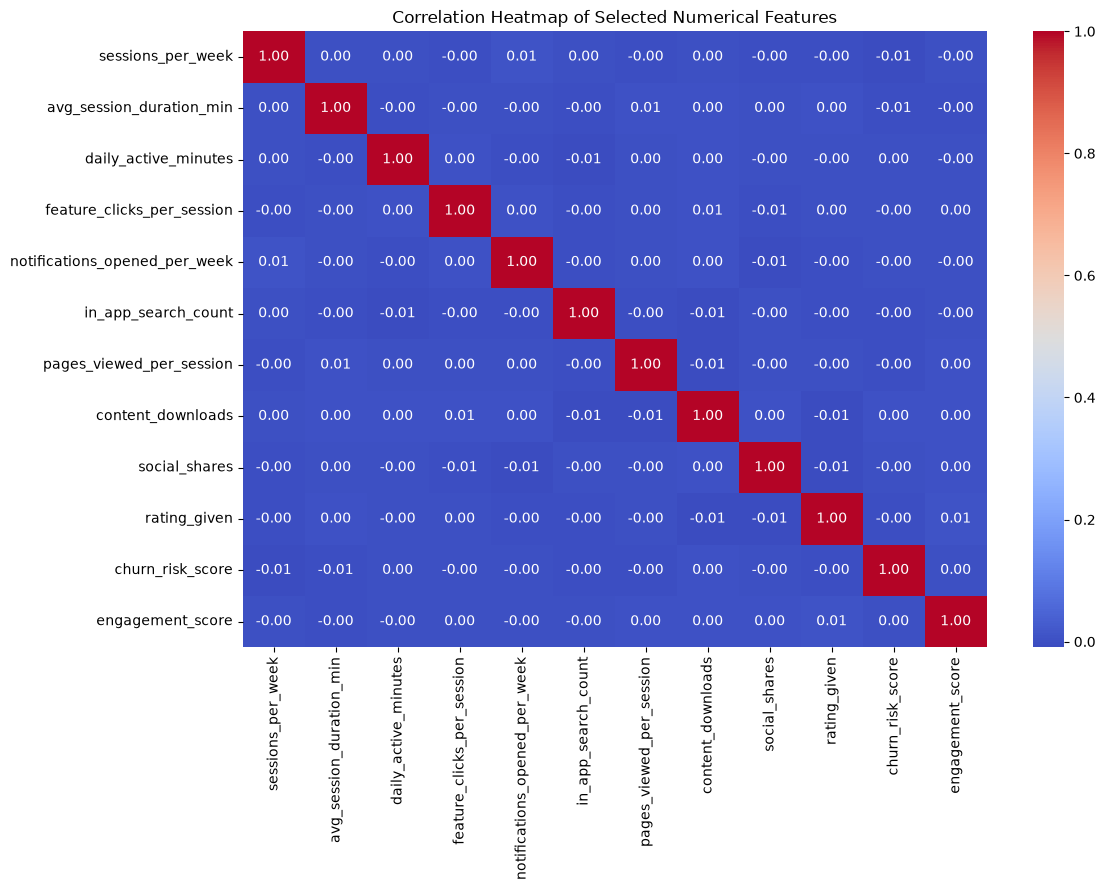

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Selected Numerical Features")
plt.show()

Exploratory Data Analysis (EDA)

5.1 Numerical Feature Distribution

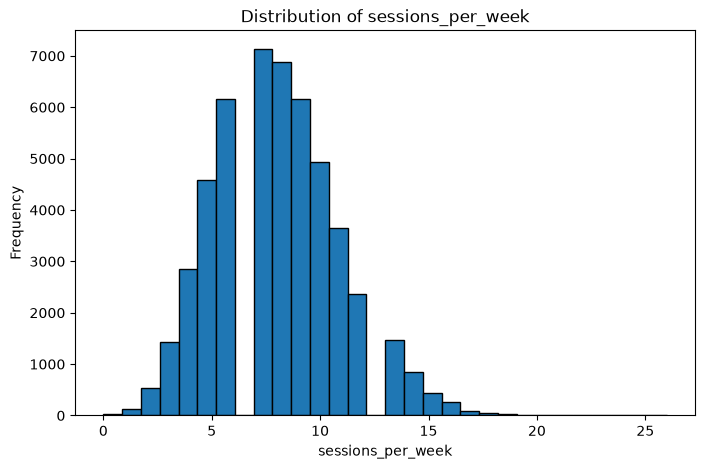

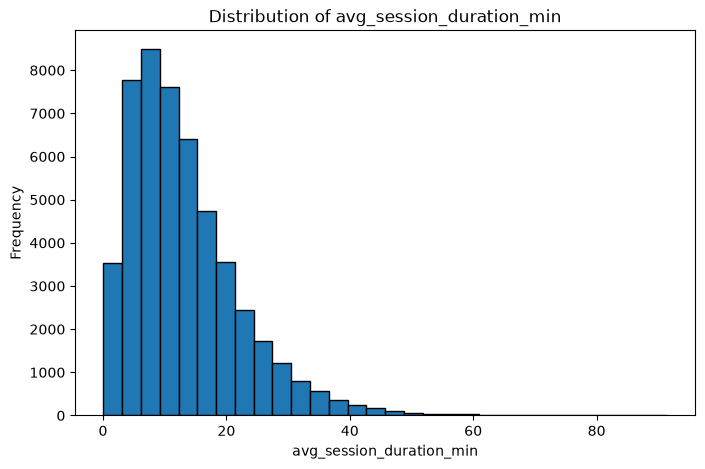

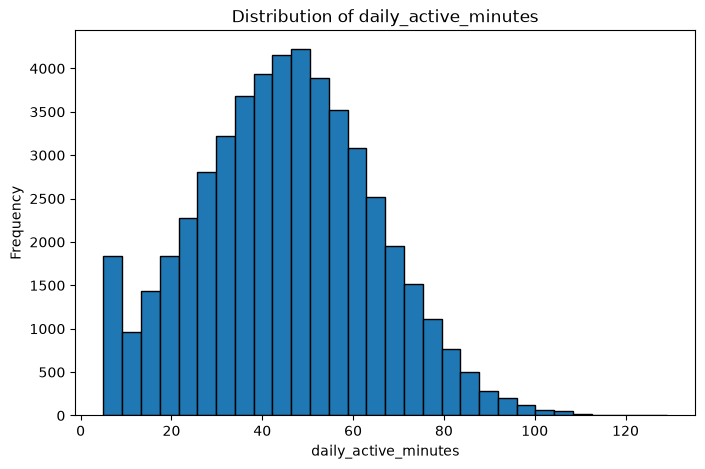

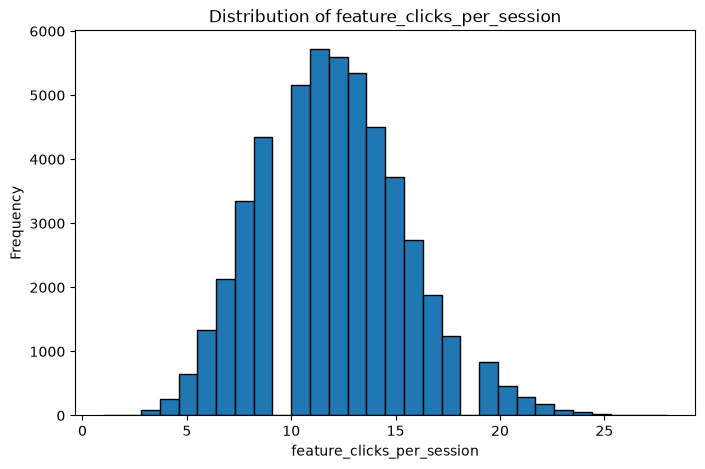

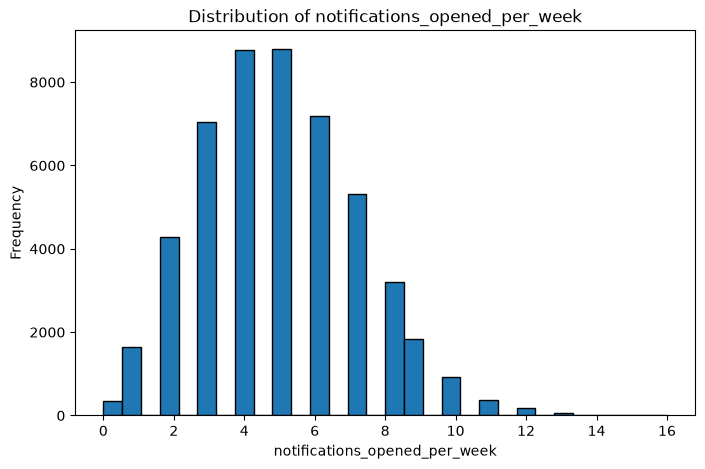

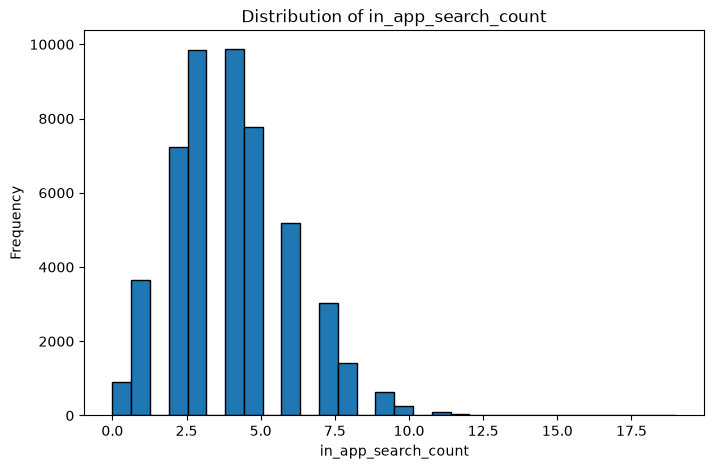

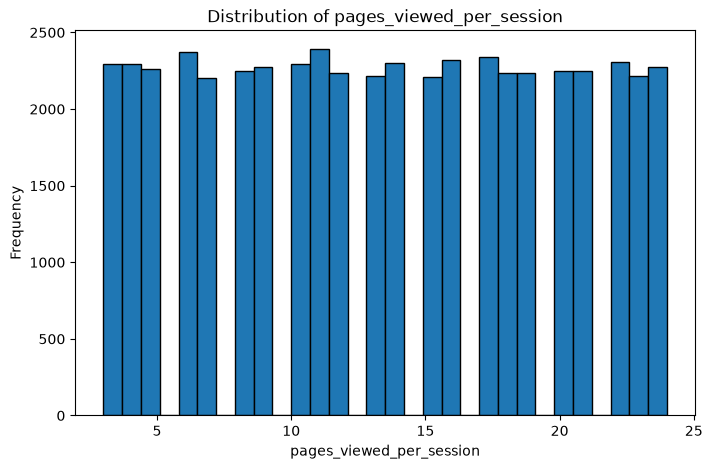

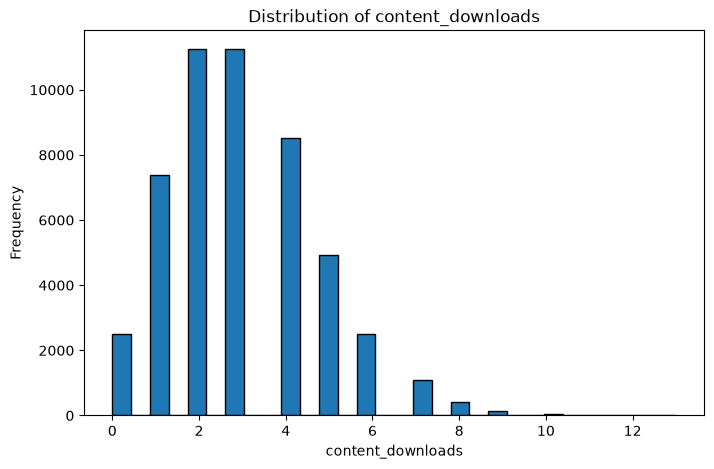

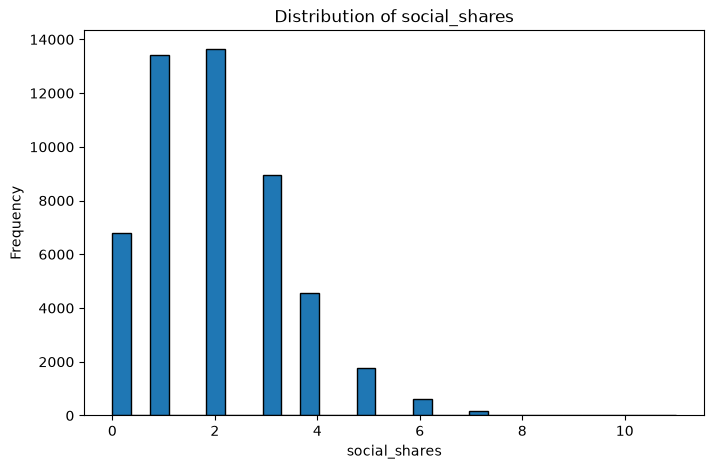

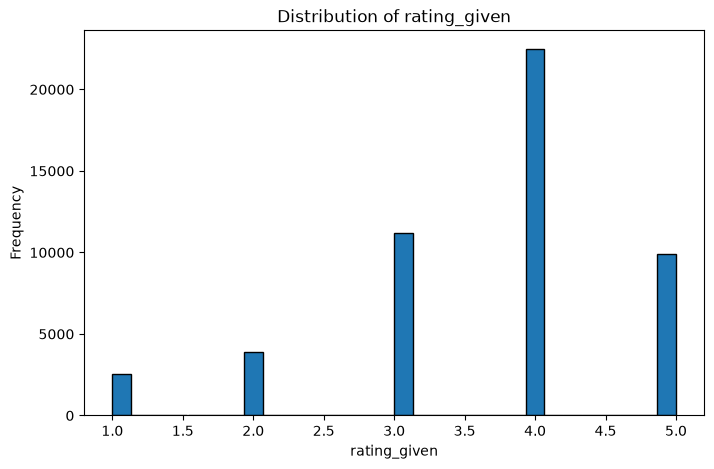

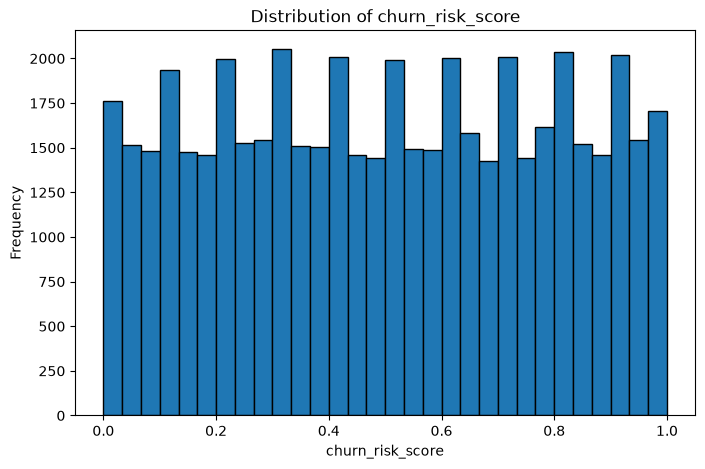

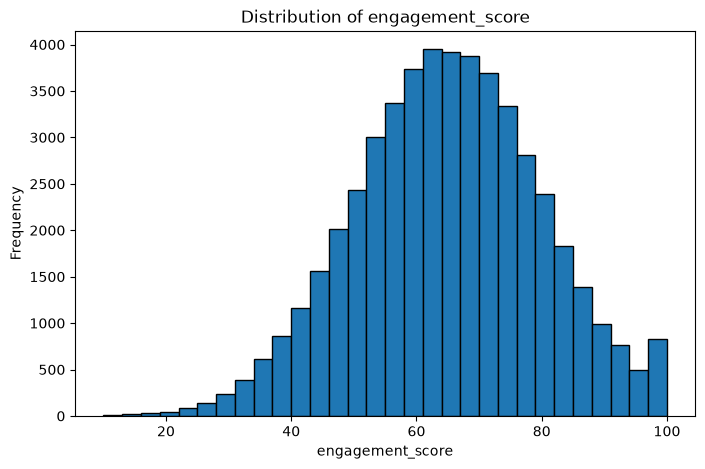

In [ ]:
for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    plt.hist(df[feature], bins=30, edgecolor='black')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

5.2 Box Plot for Numerical Features

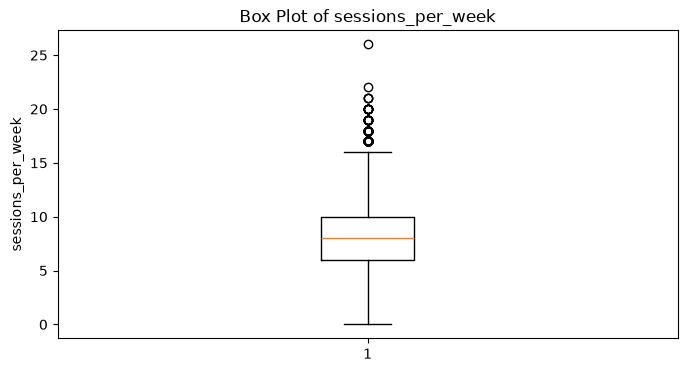

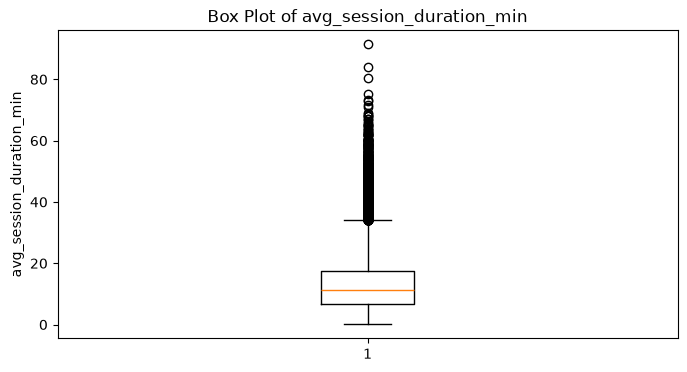

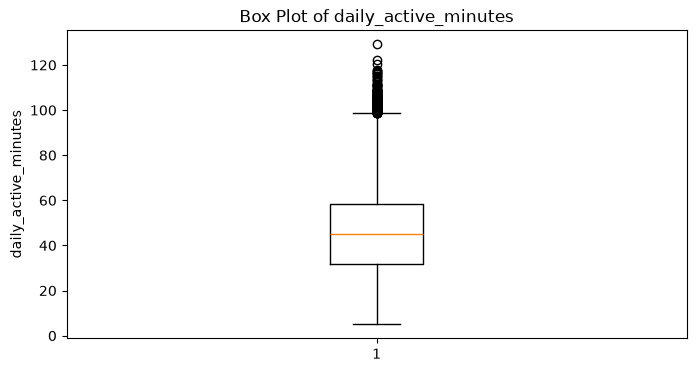

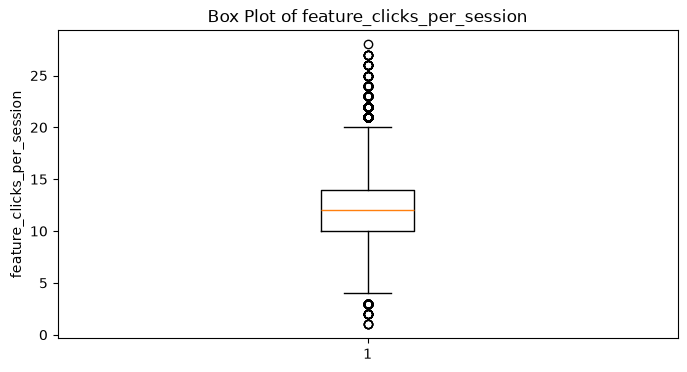

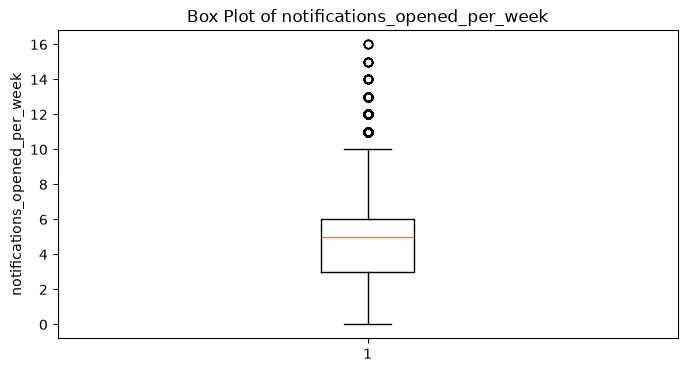

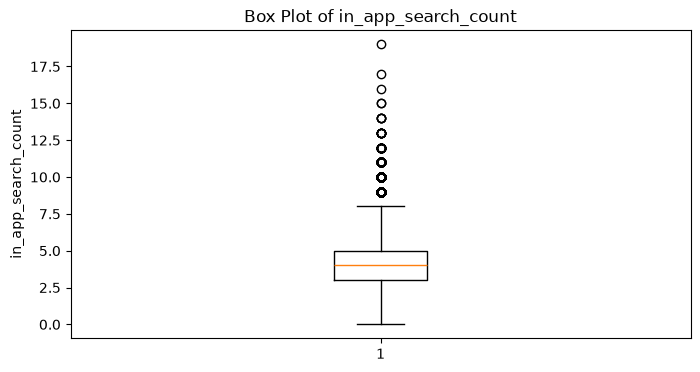

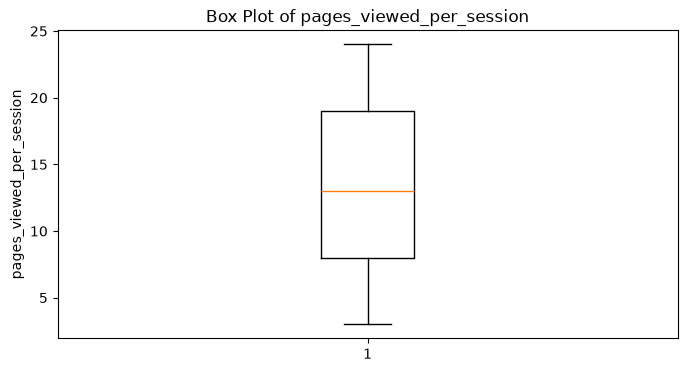

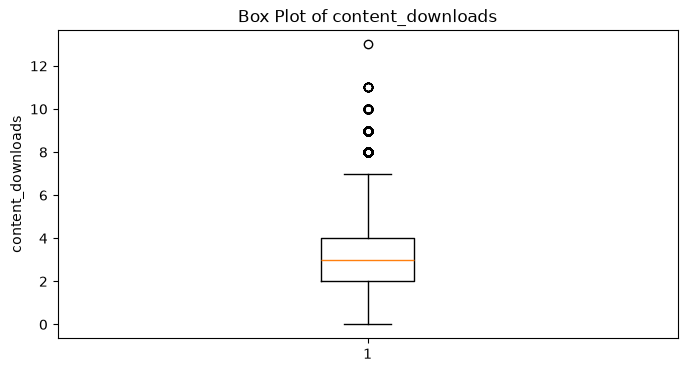

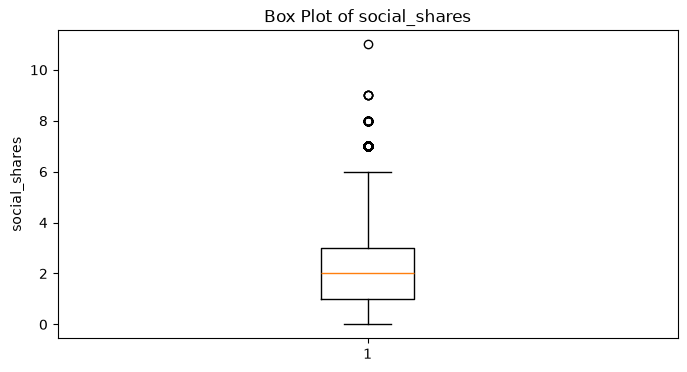

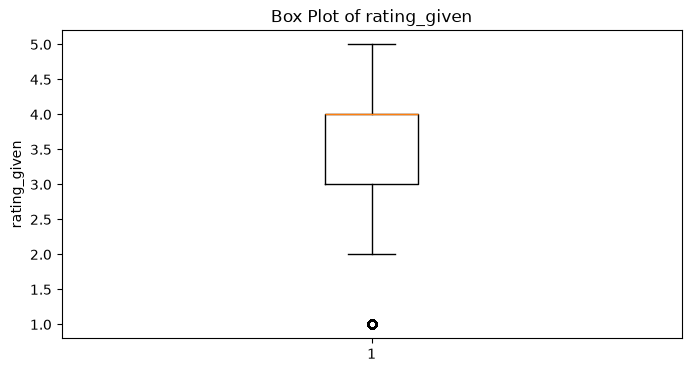

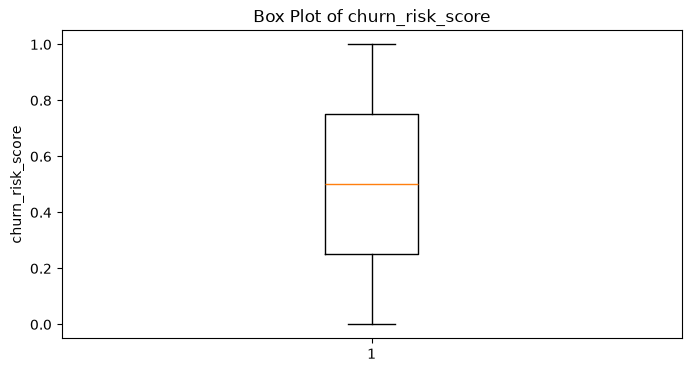

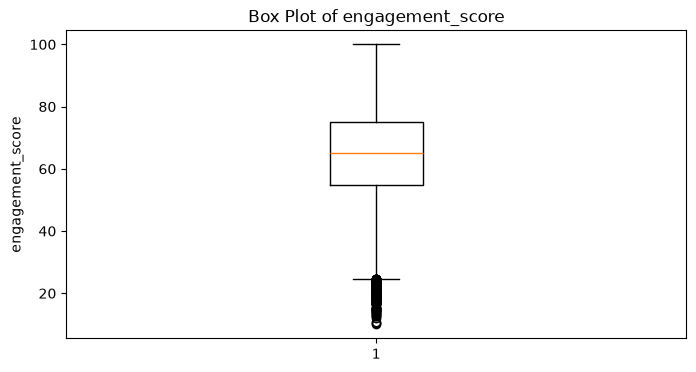

In [ ]:
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)
    plt.show()

6. Categorical Feature Analysis

6.1 Gender Distribution

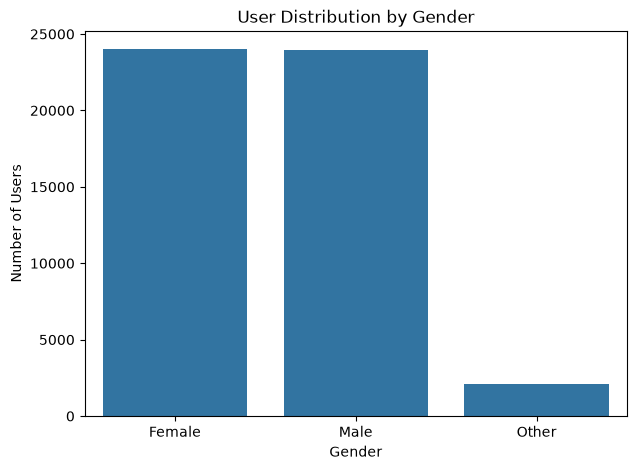

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='gender')

plt.title('User Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Users')
plt.show()

6.2 Country Distribution

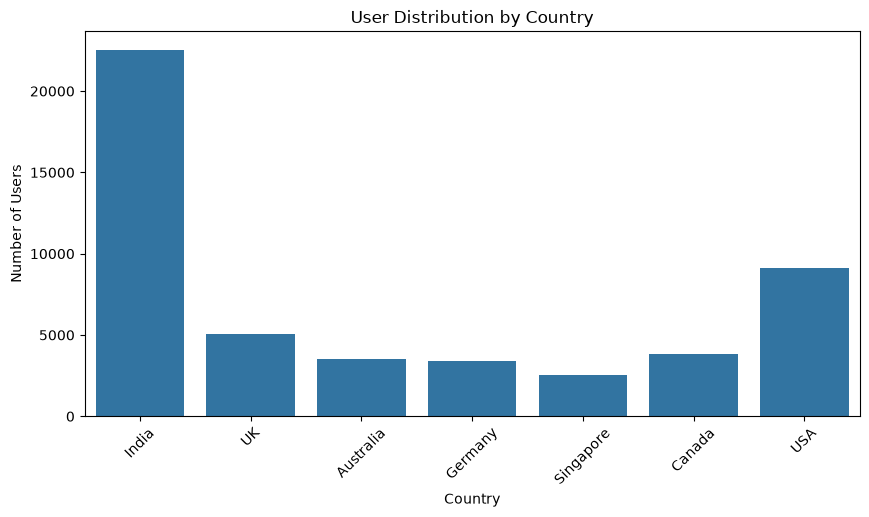

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x='country')

plt.title('User Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)

plt.show()

6.3 Device Type Distribution

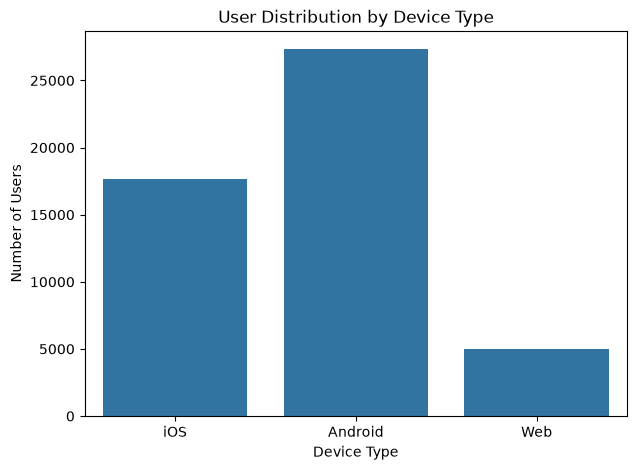

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='device_type')

plt.title('User Distribution by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Number of Users')

plt.show()

6.4 Subscription Type Distribution

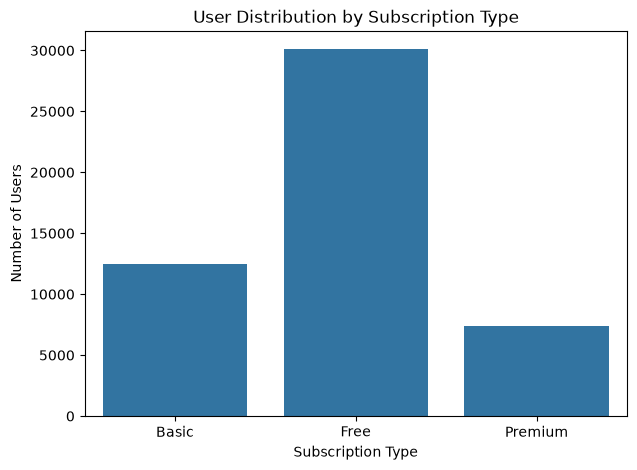

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='subscription_type')

plt.title('User Distribution by Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Number of Users')

plt.show()

6.5 Marketing Source Distribution

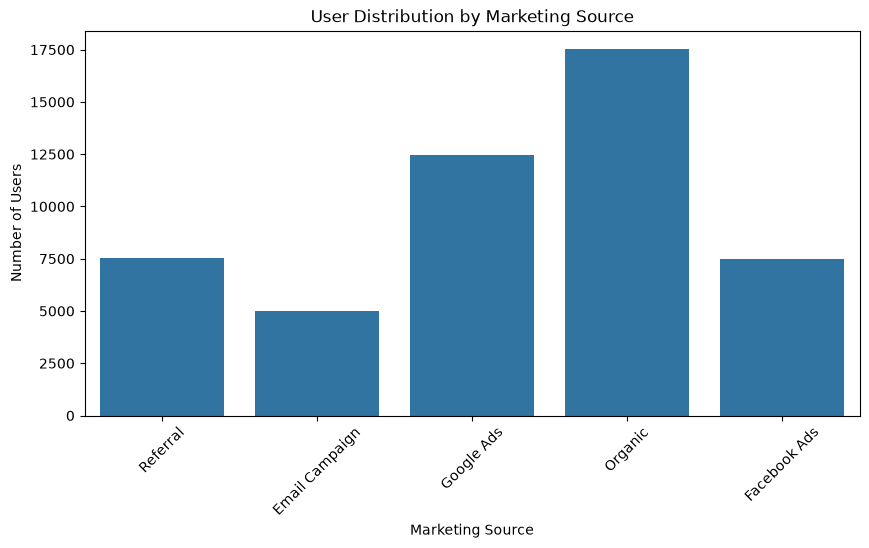

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x='marketing_source')

plt.title('User Distribution by Marketing Source')
plt.xlabel('Marketing Source')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)

plt.show()

7. Correlation Analysis

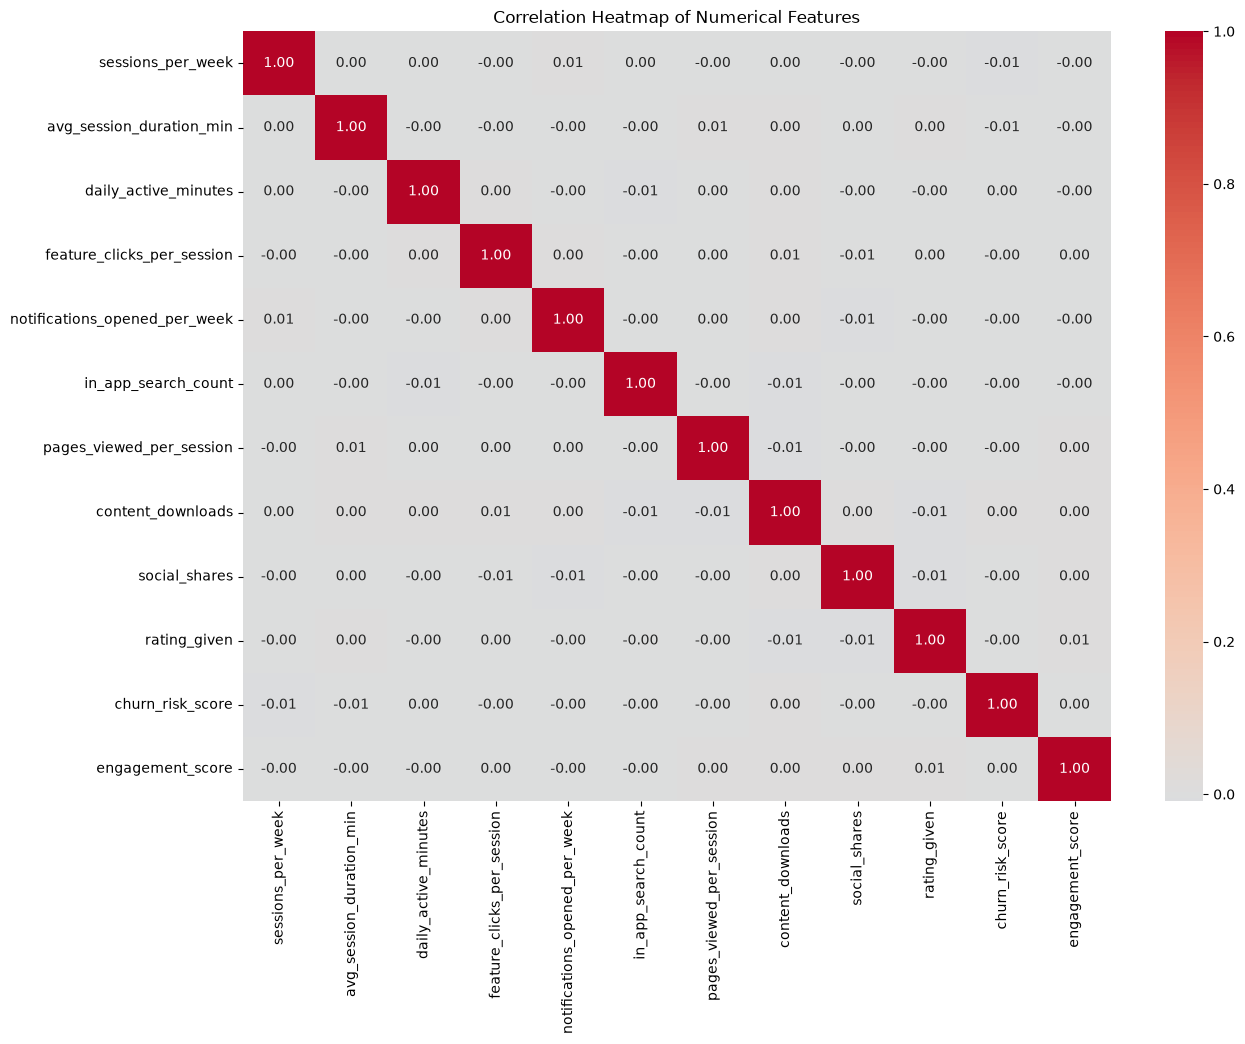

In [ ]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df_numerical.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

sessions_per_week ↔ engagement_score     ≈ -0.0008
daily_active_minutes ↔ engagement_score  ≈ -0.00
churn_risk_score ↔ engagement_score      ≈  0.00

This means there is almost no linear relationship between these variables in this dataset.

The correlation analysis shows very weak linear relationships among the selected numerical features. Therefore, further group-wise and non-linear analysis is required to understand user behavior patterns.

8. Engagement Score Analysis

8.1 Engagement Score Distribution

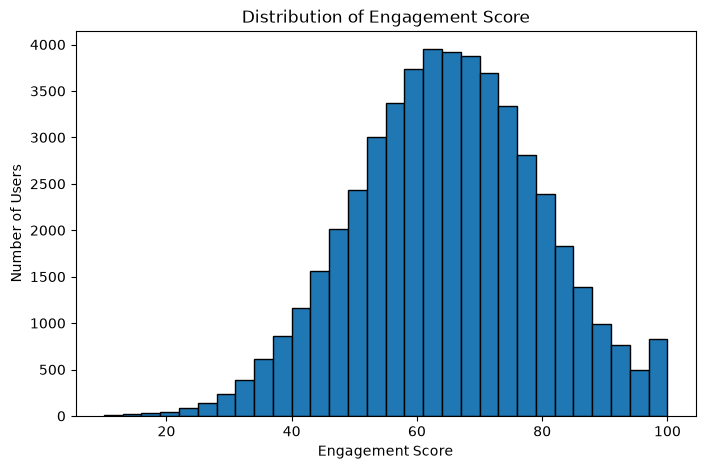

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df['engagement_score'],
    bins=30,
    edgecolor='black'
)

plt.title('Distribution of Engagement Score')
plt.xlabel('Engagement Score')
plt.ylabel('Number of Users')

plt.show()

8.2 Engagement Score by Device

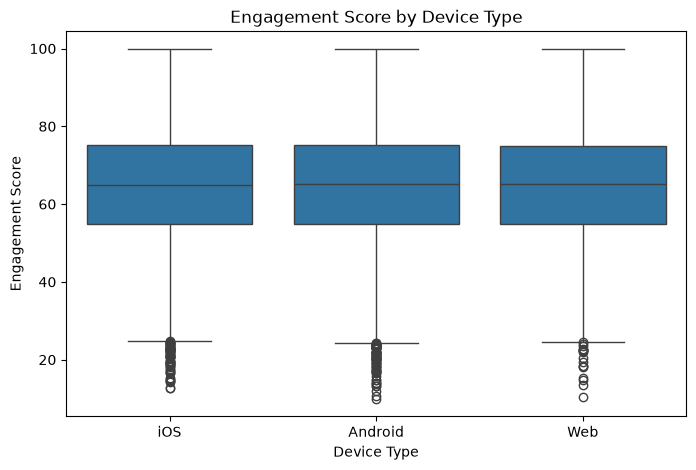

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='device_type',
    y='engagement_score'
)

plt.title('Engagement Score by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Engagement Score')

plt.show()

9. Churn Risk Analysis

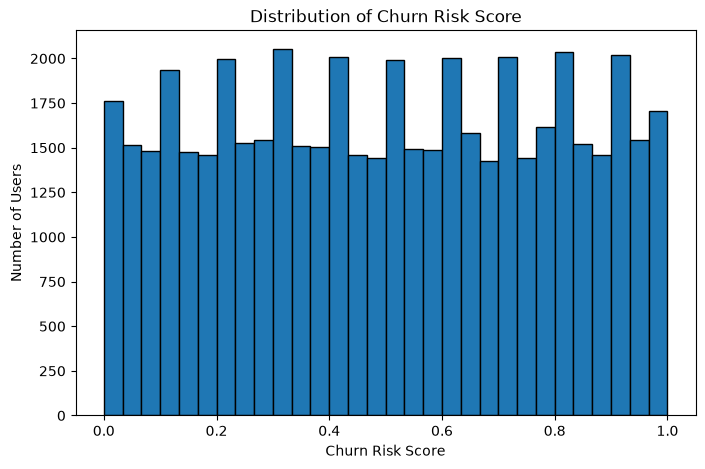

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df['churn_risk_score'],
    bins=30,
    edgecolor='black'
)

plt.title('Distribution of Churn Risk Score')
plt.xlabel('Churn Risk Score')
plt.ylabel('Number of Users')

plt.show()

9.1 Churn Risk by Subscription Type

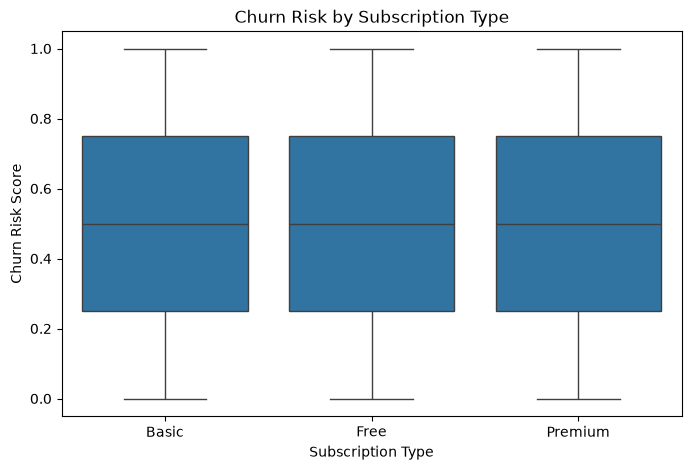

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='subscription_type',
    y='churn_risk_score'
)

plt.title('Churn Risk by Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Churn Risk Score')

plt.show()

9.2 Churn Risk by Device Type

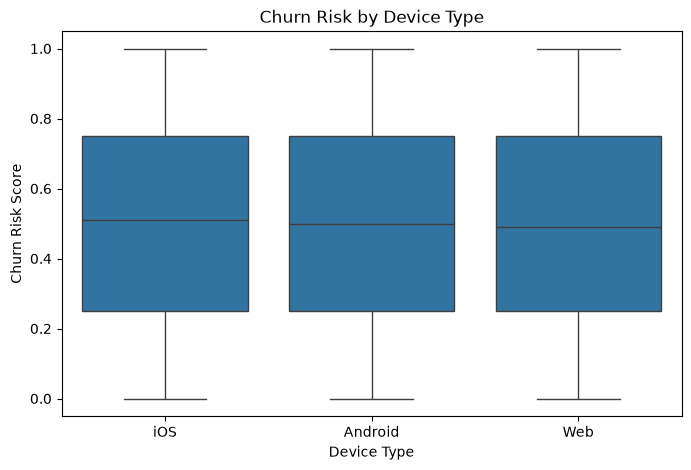

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='device_type',
    y='churn_risk_score'
)

plt.title('Churn Risk by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Churn Risk Score')

plt.show()

10. Group-wise Analysis

In [ ]:
df.groupby('device_type')['engagement_score'].mean().sort_values(ascending=False)

device_type
iOS        64.961675
Android    64.959795
Web        64.760209
Name: engagement_score, dtype: float64

Average Engagement by Device

In [ ]:
df.groupby('subscription_type')['engagement_score'].mean().sort_values(ascending=False)

subscription_type
Free       64.994637
Basic      64.916423
Premium    64.760829
Name: engagement_score, dtype: float64

Average Engagement by Subscription

In [ ]:
df.groupby('country')['engagement_score'].mean().sort_values(ascending=False)

country
Australia    65.415763
UK           65.145479
USA          65.020572
Germany      64.978707
India        64.877617
Canada       64.743281
Singapore    64.390592
Name: engagement_score, dtype: float64

Average Engagement by Country

In [ ]:
df.groupby('country')['engagement_score'].mean().sort_values(ascending=False)

country
Australia    65.415763
UK           65.145479
USA          65.020572
Germany      64.978707
India        64.877617
Canada       64.743281
Singapore    64.390592
Name: engagement_score, dtype: float64

Average Churn Risk by Subscription

In [ ]:
df.groupby('subscription_type')['churn_risk_score'].mean().sort_values(ascending=False)

subscription_type
Basic      0.500963
Premium    0.500920
Free       0.500760
Name: churn_risk_score, dtype: float64

Average Churn Risk by Device

In [ ]:
df.groupby('device_type')['churn_risk_score'].mean().sort_values(ascending=False)

device_type
iOS        0.501674
Android    0.500874
Web        0.497667
Name: churn_risk_score, dtype: float64

11. Days Since Last Login Analysis

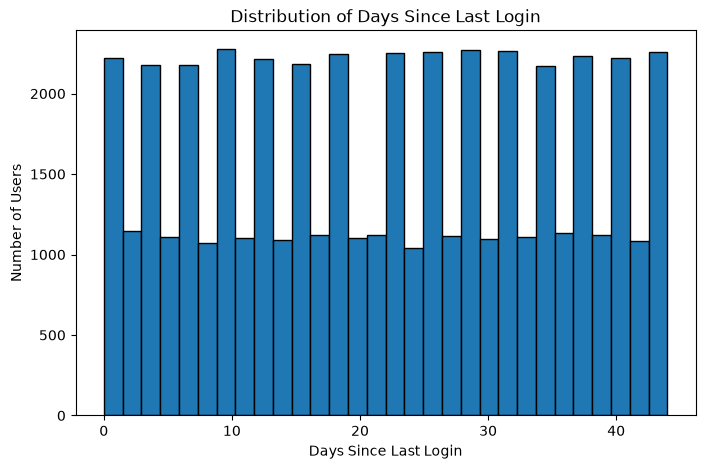

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df['days_since_last_login'],
    bins=30,
    edgecolor='black'
)

plt.title('Distribution of Days Since Last Login')
plt.xlabel('Days Since Last Login')
plt.ylabel('Number of Users')

plt.show()

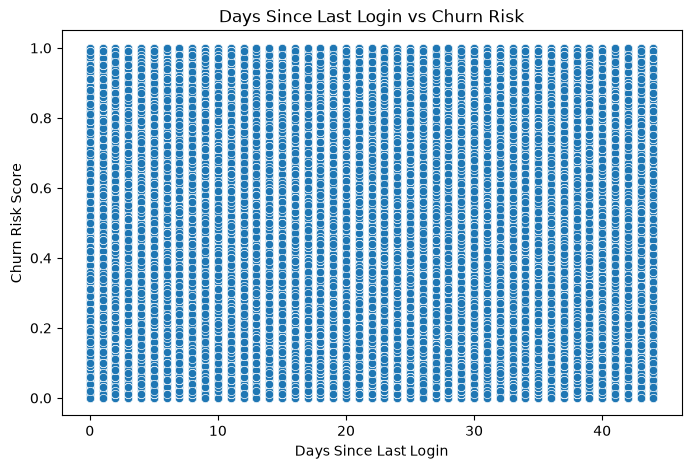

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='days_since_last_login',
    y='churn_risk_score'
)

plt.title('Days Since Last Login vs Churn Risk')
plt.xlabel('Days Since Last Login')
plt.ylabel('Churn Risk Score')

plt.show()

In [ ]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,50000.0,NaN,NaN,NaN,124999.5,14433.901067,100000.0,112499.75,124999.5,137499.25,149999.0
age,50000.0,NaN,NaN,NaN,38.51304,12.094948,18.0,28.0,39.0,49.0,59.0
gender,50000,3,Female,23994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,50000,7,India,22550,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,50000,3,Android,27315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
app_version,50000.0,NaN,NaN,NaN,1.476126,0.470158,1.0,1.1,1.2,2.0,2.1
sessions_per_week,50000.0,NaN,NaN,NaN,7.99968,2.829438,0.0,6.0,8.0,10.0,26.0
avg_session_duration_min,50000.0,NaN,NaN,NaN,13.149842,8.946944,0.06,6.57,11.24,17.57,91.4
daily_active_minutes,50000.0,NaN,NaN,NaN,45.164537,19.505118,5.0,31.65,45.21,58.44,129.13
feature_clicks_per_session,50000.0,NaN,NaN,NaN,12.01392,3.480289,1.0,10.0,12.0,14.0,28.0


Data Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaling_features = [
    'age',
    'sessions_per_week',
    'avg_session_duration_min',
    'daily_active_minutes',
    'feature_clicks_per_session',
    'notifications_opened_per_week',
    'in_app_search_count',
    'pages_viewed_per_session',
    'crash_events_last_30_days',
    'support_tickets_raised',
    'days_since_last_login',
    'ads_clicked_last_30_days',
    'content_downloads',
    'social_shares',
    'rating_given',
    'churn_risk_score',
    'engagement_score',
    'account_age_days'
]

df_scaling = df[scaling_features].copy()

print("Features selected for scaling:")
print(df_scaling.columns.tolist())

Features selected for scaling:
['age', 'sessions_per_week', 'avg_session_duration_min', 'daily_active_minutes', 'feature_clicks_per_session', 'notifications_opened_per_week', 'in_app_search_count', 'pages_viewed_per_session', 'crash_events_last_30_days', 'support_tickets_raised', 'days_since_last_login', 'ads_clicked_last_30_days', 'content_downloads', 'social_shares', 'rating_given', 'churn_risk_score', 'engagement_score', 'account_age_days']


In [ ]:
scaler = StandardScaler()

In [ ]:
scaled_data = scaler.fit_transform(df_scaling)

In [ ]:
df_scaled = pd.DataFrame(
    scaled_data,
    columns=scaling_features,
    index=df.index
)

df_scaled.head()

,age,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days
0,1.445821,-1.060179,-1.088633,0.386849,0.283336,0.001512,2.002730,-0.862410,0.950305,-0.442514,-0.156968,1.224561,1.153562,-0.001019,0.320313,-0.661298,-0.616659,1.586435
1,0.619022,0.000113,1.261914,-0.160705,-1.440677,0.896304,-0.500094,-1.020050,-0.627017,-0.442514,-1.158114,0.816944,-0.001305,0.706485,-0.643788,1.279270,1.175953,1.317310
2,-0.538498,1.413835,-0.872915,1.616282,-1.440677,0.001512,-1.000659,1.186909,0.950305,-0.442514,0.844179,2.039793,1.730996,-0.708522,-1.607890,0.447598,-1.512965,0.214765
3,-1.117258,-1.060179,-1.024924,1.036429,1.145342,1.343700,0.000471,-0.074211,-0.627017,-0.442514,-0.388001,0.001712,-0.001305,-0.708522,-0.643788,-0.245462,-0.143571,-1.481014
4,-0.042418,0.706974,-0.033514,0.609870,0.283336,0.896304,-0.500094,0.241069,-0.627017,-0.442514,-0.079956,-0.813520,0.576129,-0.001019,1.284415,-0.245462,-1.801401,0.486784


In [ ]:
print("Mean after scaling:")
print(df_scaled.mean().round(2))

print("\nStandard deviation after scaling:")
print(df_scaled.std().round(2))

Mean after scaling:
age                              0.0
sessions_per_week                0.0
avg_session_duration_min        -0.0
daily_active_minutes            -0.0
feature_clicks_per_session      -0.0
notifications_opened_per_week   -0.0
in_app_search_count             -0.0
pages_viewed_per_session        -0.0
crash_events_last_30_days        0.0
support_tickets_raised          -0.0
days_since_last_login            0.0
ads_clicked_last_30_days        -0.0
content_downloads               -0.0
social_shares                   -0.0
rating_given                     0.0
churn_risk_score                 0.0
engagement_score                 0.0
account_age_days                -0.0
dtype: float64

Standard deviation after scaling:
age                              1.0
sessions_per_week                1.0
avg_session_duration_min         1.0
daily_active_minutes             1.0
feature_clicks_per_session       1.0
notifications_opened_per_week    1.0
in_app_search_count              1.0
pages

In [ ]:
print("Original data shape:", df_scaling.shape)
print("Scaled data shape:", df_scaled.shape)

Original data shape: (50000, 18)
Scaled data shape: (50000, 18)


In [ ]:
comparison = pd.DataFrame({
    'Original_Sessions': df['sessions_per_week'].head(),
    'Scaled_Sessions': df_scaled['sessions_per_week'].head(),
    'Original_Engagement': df['engagement_score'].head(),
    'Scaled_Engagement': df_scaled['engagement_score'].head()
})

print(comparison)

   Original_Sessions  Scaled_Sessions  Original_Engagement  Scaled_Engagement
0                  5        -1.060179                55.79          -0.616659
1                  8         0.000113                82.39           1.175953
2                 12         1.413835                42.49          -1.512965
3                  5        -1.060179                62.81          -0.143571
4                 10         0.706974                38.21          -1.801401


In [ ]:
df_scaled.describe()

,age,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days
count,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04
mean,2.842881e-16,1.300293e-16,-1.453060e-16,-2.685852e-17,-1.645617e-16,-8.881784e-18,-1.056932e-17,-4.746425e-17,5.819345e-17,-4.192202e-17,1.394085e-16,-8.455459e-18,-9.059420e-17,-8.924417e-17,5.762502e-17,3.371525e-16,1.105107e-15,-1.624301e-16
std,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00
min,-1.696018e+00,-2.827332e+00,-1.463066e+00,-2.059200e+00,-3.164689e+00,-2.235467e+00,-2.001789e+00,-1.650609e+00,-6.270173e-01,-4.425141e-01,-1.697193e+00,-2.443985e+00,-1.733606e+00,-1.416026e+00,-2.571992e+00,-1.735541e+00,-3.702513e+00,-1.726988e+00
25%,-8.692179e-01,-7.067481e-01,-7.354364e-01,-6.928783e-01,-5.786704e-01,-8.932794e-01,-5.000942e-01,-8.624100e-01,-6.270173e-01,-4.425141e-01,-8.500692e-01,-8.135204e-01,-5.787385e-01,-7.085223e-01,-6.437885e-01,-8.692165e-01,-6.766376e-01,-8.733116e-01
50%,4.026184e-02,1.130978e-04,-2.134652e-01,2.330858e-03,-3.999708e-03,1.512198e-03,4.705309e-04,-7.421056e-02,-6.270173e-01,-4.425141e-01,-2.944912e-03,1.711988e-03,-1.305000e-03,-1.018805e-03,3.203131e-01,-2.891446e-03,5.700737e-03,6.218818e-04
75%,8.670616e-01,7.069743e-01,4.940460e-01,6.806212e-01,5.706710e-01,4.489080e-01,5.010353e-01,8.716288e-01,9.503054e-01,-4.425141e-01,8.441794e-01,8.169444e-01,5.761285e-01,7.064847e-01,3.203131e-01,8.634336e-01,6.839956e-01,8.745553e-01
max,1.693861e+00,6.361864e+00,8.746108e+00,4.304834e+00,4.593366e+00,4.922866e+00,7.508942e+00,1.659828e+00,7.259596e+00,8.558079e+00,1.691304e+00,5.300723e+00,5.773030e+00,6.366512e+00,1.284415e+00,1.729759e+00,2.362717e+00,1.722444e+00


In [ ]:
X = df_scaled.copy()

print("Final clustering dataset shape:", X.shape)
print(X.head())

Final clustering dataset shape: (50000, 18)
        age  sessions_per_week  avg_session_duration_min  \
0  1.445821          -1.060179                 -1.088633   
1  0.619022           0.000113                  1.261914   
2 -0.538498           1.413835                 -0.872915   
3 -1.117258          -1.060179                 -1.024924   
4 -0.042418           0.706974                 -0.033514   

   daily_active_minutes  feature_clicks_per_session  \
0              0.386849                    0.283336   
1             -0.160705                   -1.440677   
2              1.616282                   -1.440677   
3              1.036429                    1.145342   
4              0.609870                    0.283336   

   notifications_opened_per_week  in_app_search_count  \
0                       0.001512             2.002730   
1                       0.896304            -0.500094   
2                       0.001512            -1.000659   
3                       1.343700    

Data Scaling: Applied StandardScaler to the selected numerical features. The features were standardized to a mean of approximately 0 and a standard deviation of 1, ensuring that variables with different scales contribute equally to the clustering algorithm.

Clustering Model Selection

For 50,000 records, scalability is an important consideration. Therefore, K-Means is a strong candidate, while Hierarchical and DBSCAN need to be evaluated carefully.

1.1 Import Required Libraries

In [ ]:
from sklearn.cluster import (
    KMeans,
    MiniBatchKMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

1.2 K-Means Clustering

K-Means divides users into a predefined number of clusters by minimizing the distance between users and their cluster centers.

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X)

print("K-Means completed.")

K-Means completed.


In [ ]:
kmeans_silhouette = silhouette_score(X, kmeans_labels)

kmeans_db = davies_bouldin_score(X, kmeans_labels)

kmeans_ch = calinski_harabasz_score(X, kmeans_labels)

print("K-Means Results")
print("Silhouette Score:", round(kmeans_silhouette, 4))
print("Davies-Bouldin Score:", round(kmeans_db, 4))
print("Calinski-Harabasz Score:", round(kmeans_ch, 4))

K-Means Results
Silhouette Score: 0.043
Davies-Bouldin Score: 3.79
Calinski-Harabasz Score: 2089.3143


1.3 MiniBatch K-Means

MiniBatch K-Means is a faster version of K-Means that processes small batches of data.

In [ ]:
mini_kmeans = MiniBatchKMeans(
    n_clusters=4,
    random_state=42,
    batch_size=1024,
    n_init=10
)

mini_labels = mini_kmeans.fit_predict(X)

print("MiniBatch K-Means completed.")

MiniBatch K-Means completed.


In [ ]:
mini_silhouette = silhouette_score(X, mini_labels)

mini_db = davies_bouldin_score(X, mini_labels)

mini_ch = calinski_harabasz_score(X, mini_labels)

print("MiniBatch K-Means Results")
print("Silhouette Score:", round(mini_silhouette, 4))
print("Davies-Bouldin Score:", round(mini_db, 4))
print("Calinski-Harabasz Score:", round(mini_ch, 4))

MiniBatch K-Means Results
Silhouette Score: 0.0322
Davies-Bouldin Score: 4.1067
Calinski-Harabasz Score: 1530.6474


1.4 Agglomerative Clustering

Agglomerative Clustering creates a hierarchy of clusters by progressively merging similar users.

In [ ]:
sample_size = 5000

X_sample = X.sample(
    n=sample_size,
    random_state=42
)

In [ ]:
agglo = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

agglo_labels = agglo.fit_predict(X_sample)

print("Agglomerative Clustering completed.")

Agglomerative Clustering completed.


In [ ]:
agglo_silhouette = silhouette_score(
    X_sample,
    agglo_labels
)

agglo_db = davies_bouldin_score(
    X_sample,
    agglo_labels
)

agglo_ch = calinski_harabasz_score(
    X_sample,
    agglo_labels
)

print("Agglomerative Results")
print("Silhouette Score:", round(agglo_silhouette, 4))
print("Davies-Bouldin Score:", round(agglo_db, 4))
print("Calinski-Harabasz Score:", round(agglo_ch, 4))

Agglomerative Results
Silhouette Score: 0.0377
Davies-Bouldin Score: 3.8153
Calinski-Harabasz Score: 122.2921


1.5 DBSCAN

DBSCAN is different from K-Means because it does not require the number of clusters beforehand.

In [ ]:
dbscan = DBSCAN(
    eps=2.0,
    min_samples=10,
    n_jobs=-1
)

dbscan_labels = dbscan.fit_predict(X)

print("DBSCAN completed.")

DBSCAN completed.


In [ ]:
unique_labels = np.unique(dbscan_labels)

print("Clusters found:", unique_labels)

Clusters found: [-1  0  1  2  3]


Do not assume eps=2.0 is the best value. DBSCAN is highly sensitive to eps and min_samples, so these parameters should be tuned.

In [ ]:
n_clusters_dbscan = len(
    set(dbscan_labels) - {-1}
)

n_noise = np.sum(
    dbscan_labels == -1
)

print("Number of clusters:", n_clusters_dbscan)
print("Number of noise points:", n_noise)

Number of clusters: 4
Number of noise points: 49952


In [ ]:
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) >= 2:

    dbscan_silhouette = silhouette_score(
        X[mask],
        dbscan_labels[mask]
    )

    dbscan_db = davies_bouldin_score(
        X[mask],
        dbscan_labels[mask]
    )

    dbscan_ch = calinski_harabasz_score(
        X[mask],
        dbscan_labels[mask]
    )

    print("DBSCAN Results")
    print("Silhouette Score:", round(dbscan_silhouette, 4))
    print("Davies-Bouldin Score:", round(dbscan_db, 4))
    print("Calinski-Harabasz Score:", round(dbscan_ch, 4))

DBSCAN Results
Silhouette Score: 0.2726
Davies-Bouldin Score: 1.2897
Calinski-Harabasz Score: 14.5921


1.7 Gaussian Mixture Model

GMM is a probabilistic clustering method.

Unlike K-Means, a user can have a probability of belonging to each cluster.

In [ ]:
gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

gmm_labels = gmm.fit_predict(X)

print("Gaussian Mixture Model completed.")

Gaussian Mixture Model completed.


In [ ]:
gmm_silhouette = silhouette_score(
    X,
    gmm_labels
)

gmm_db = davies_bouldin_score(
    X,
    gmm_labels
)

gmm_ch = calinski_harabasz_score(
    X,
    gmm_labels
)

print("GMM Results")
print("Silhouette Score:", round(gmm_silhouette, 4))
print("Davies-Bouldin Score:", round(gmm_db, 4))
print("Calinski-Harabasz Score:", round(gmm_ch, 4))

GMM Results
Silhouette Score: 0.0253
Davies-Bouldin Score: 4.3299
Calinski-Harabasz Score: 1209.2224


1.8 Compare All Models

In [ ]:
results = pd.DataFrame({
    'Model': [
        'K-Means',
        'MiniBatch K-Means',
        'Agglomerative',
        'Gaussian Mixture'
    ],

    'Silhouette Score': [
        kmeans_silhouette,
        mini_silhouette,
        agglo_silhouette,
        gmm_silhouette
    ],

    'Davies-Bouldin Score': [
        kmeans_db,
        mini_db,
        agglo_db,
        gmm_db
    ],

    'Calinski-Harabasz Score': [
        kmeans_ch,
        mini_ch,
        agglo_ch,
        gmm_ch
    ]
})

print(results)

               Model  Silhouette Score  Davies-Bouldin Score  \
0            K-Means          0.043039              3.790049   
1  MiniBatch K-Means          0.032229              4.106690   
2      Agglomerative          0.037740              3.815313   
3   Gaussian Mixture          0.025252              4.329936   

   Calinski-Harabasz Score  
0              2089.314278  
1              1530.647411  
2               122.292126  
3              1209.222362  


Understand the Evaluation Metrics
Silhouette Score

Higher is better.

Closer to +1 → Better separated clusters
Around 0     → Overlapping clusters
Negative     → Poor clustering
Davies-Bouldin Score

Lower is better.

Lower value → Compact and well-separated clusters
Higher value → More overlapping clusters
Calinski-Harabasz Score

Higher is generally better.

Higher value → Better-defined clusters

So when comparing models:

Silhouette ↑ + Calinski-Harabasz ↑ + Davies-Bouldin ↓ = Better clustering

Final Selection Code

In [ ]:
from sklearn.cluster import KMeans

optimal_k = 4

final_kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(X)

print("Final K-Means model created successfully.")

Final K-Means model created successfully.


In [ ]:
df['cluster'] = final_labels

print(df['cluster'].value_counts().sort_index())

cluster
0    11716
1     8393
2    14724
3    15167
Name: count, dtype: int64


Final Model Evaluation

In [ ]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

final_silhouette = silhouette_score(X, final_labels)

final_db = davies_bouldin_score(X, final_labels)

final_ch = calinski_harabasz_score(X, final_labels)

print("Final K-Means Performance")
print("-------------------------")
print("Silhouette Score:", round(final_silhouette, 4))
print("Davies-Bouldin Score:", round(final_db, 4))
print("Calinski-Harabasz Score:", round(final_ch, 4))

Final K-Means Performance
-------------------------
Silhouette Score: 0.043
Davies-Bouldin Score: 3.79
Calinski-Harabasz Score: 2089.3143


Now we have the actual comparison results, so we can make a proper model-selection decision instead of assuming K-Means is best.

Best Model

Based on all three evaluation metrics, K-Means is the best-performing model among the tested algorithms.

Silhouette Score: K-Means = 0.0430, the highest among the models.
Davies-Bouldin Score: K-Means = 3.7900, the lowest.
Calinski-Harabasz Score: K-Means = 2089.31, the highest.

Therefore, K-Means is selected as the final clustering algorithm for this project.

9. Cluster-Level User Identification & Profiling

9.1 Check Cluster Distribution

In [ ]:
cluster_counts = df['cluster'].value_counts().sort_index()

print("Number of users in each cluster:")
print(cluster_counts)

#Cluster Percentage
cluster_percentage = (
    df['cluster']
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Percentage of users in each cluster:")
print(cluster_percentage.round(2))

Number of users in each cluster:
cluster
0    11716
1     8393
2    14724
3    15167
Name: count, dtype: int64
Percentage of users in each cluster:
cluster
0    23.43
1    16.79
2    29.45
3    30.33
Name: proportion, dtype: float64


9.2 Identify User IDs in Each Cluster

In [ ]:
cluster_0_users = df.loc[
    df['cluster'] == 0,
    'user_id'
]

print(cluster_0_users.head(20))

0     100000
2     100002
10    100010
15    100015
17    100017
20    100020
21    100021
29    100029
31    100031
37    100037
42    100042
43    100043
51    100051
53    100053
64    100064
65    100065
68    100068
69    100069
78    100078
80    100080
Name: user_id, dtype: int64


In [ ]:
cluster_1_users = df.loc[
    df['cluster'] == 1,
    'user_id'
]

print(cluster_1_users.head(20))

8      100008
13     100013
28     100028
41     100041
48     100048
52     100052
55     100055
58     100058
62     100062
75     100075
79     100079
82     100082
83     100083
86     100086
91     100091
111    100111
118    100118
124    100124
127    100127
128    100128
Name: user_id, dtype: int64


In [ ]:
cluster_2_users = df.loc[
    df['cluster'] == 2,
    'user_id'
]

print(cluster_2_users.head(20))



1     100001
4     100004
6     100006
12    100012
14    100014
16    100016
25    100025
26    100026
27    100027
30    100030
36    100036
44    100044
46    100046
47    100047
54    100054
60    100060
61    100061
63    100063
66    100066
70    100070
Name: user_id, dtype: int64


In [ ]:
cluster_3_users = df.loc[
    df['cluster'] == 3,
    'user_id'
]

print(cluster_3_users.head(20))

3     100003
5     100005
7     100007
9     100009
11    100011
18    100018
19    100019
22    100022
23    100023
24    100024
32    100032
33    100033
34    100034
35    100035
38    100038
39    100039
40    100040
45    100045
49    100049
50    100050
Name: user_id, dtype: int64


9.3 Create a User List for Every Cluster

In [ ]:
cluster_users = {}

for cluster in sorted(df['cluster'].unique()):

    cluster_users[cluster] = df.loc[
        df['cluster'] == cluster,
        'user_id'
    ].tolist()

    print(
        f"Cluster {cluster}: "
        f"{len(cluster_users[cluster])} users"
    )

Cluster 0: 11716 users
Cluster 1: 8393 users
Cluster 2: 14724 users
Cluster 3: 15167 users


9.4 Create Cluster Profile

Now we need to understand what makes each cluster different.

In [ ]:
profile_features = [
    'age',
    'sessions_per_week',
    'avg_session_duration_min',
    'daily_active_minutes',
    'feature_clicks_per_session',
    'notifications_opened_per_week',
    'in_app_search_count',
    'pages_viewed_per_session',
    'content_downloads',
    'social_shares',
    'rating_given',
    'churn_risk_score',
    'engagement_score',
    'account_age_days'
]

In [ ]:
cluster_profile = df.groupby('cluster')[profile_features].mean()

print(cluster_profile.round(2))

           age  sessions_per_week  avg_session_duration_min  \
cluster                                                       
0        38.52               7.98                     13.04   
1        38.49               8.02                     13.21   
2        38.48               8.07                     13.09   
3        38.55               7.93                     13.26   

         daily_active_minutes  feature_clicks_per_session  \
cluster                                                     
0                       44.99                       11.99   
1                       45.11                       11.96   
2                       45.09                       11.98   
3                       45.39                       12.09   

         notifications_opened_per_week  in_app_search_count  \
cluster                                                       
0                                 4.96                 4.01   
1                                 5.01                 4.00   
2 

9.5 Add User Count to Profile

In [ ]:
cluster_profile['user_count'] = (
    df.groupby('cluster').size()
)

cluster_profile['percentage'] = (
    cluster_profile['user_count']
    / len(df) * 100
)

print(cluster_profile.round(2))

           age  sessions_per_week  avg_session_duration_min  \
cluster                                                       
0        38.52               7.98                     13.04   
1        38.49               8.02                     13.21   
2        38.48               8.07                     13.09   
3        38.55               7.93                     13.26   

         daily_active_minutes  feature_clicks_per_session  \
cluster                                                     
0                       44.99                       11.99   
1                       45.11                       11.96   
2                       45.09                       11.98   
3                       45.39                       12.09   

         notifications_opened_per_week  in_app_search_count  \
cluster                                                       
0                                 4.96                 4.01   
1                                 5.01                 4.00   
2 

9.6 Transpose the Profile

In [ ]:
cluster_profile.T

cluster,0,1,2,3
age,38.524838,38.491124,38.480168,38.547966
sessions_per_week,7.982759,8.023829,8.071516,7.929650
avg_session_duration_min,13.038483,13.205416,13.093237,13.260061
daily_active_minutes,44.993354,45.113927,45.093480,45.393757
feature_clicks_per_session,11.993940,11.959013,11.982138,12.090591
notifications_opened_per_week,4.962445,5.011319,4.984923,5.026241
in_app_search_count,4.009133,4.000953,4.013244,3.976462
pages_viewed_per_session,13.501024,13.458120,13.370076,13.552120
content_downloads,3.019205,2.990826,3.031106,2.967495
social_shares,2.008450,2.011557,2.013108,1.979099


cluster_profile.T

9.7 Compare Engagement Score

In [ ]:
engagement_by_cluster = (
    df.groupby('cluster')['engagement_score']
    .mean()
    .sort_values(ascending=False)
)

print(engagement_by_cluster.round(2))

cluster
3    64.99
2    64.95
0    64.94
1    64.84
Name: engagement_score, dtype: float64


This tells us which cluster has the highest engagement.

9.8 Compare Churn Risk

In [ ]:
churn_by_cluster = (
    df.groupby('cluster')['churn_risk_score']
    .mean()
    .sort_values(ascending=False)
)

print(churn_by_cluster.round(2))

cluster
0    0.51
2    0.50
1    0.50
3    0.50
Name: churn_risk_score, dtype: float64


Higher churn risk = greater likelihood of user disengagement.

9.9 Compare Session Behavior

In [ ]:
session_profile = df.groupby('cluster')[
    [
        'sessions_per_week',
        'avg_session_duration_min',
        'daily_active_minutes'
    ]
].mean()

print(session_profile.round(2))

         sessions_per_week  avg_session_duration_min  daily_active_minutes
cluster                                                                   
0                     7.98                     13.04                 44.99
1                     8.02                     13.21                 45.11
2                     8.07                     13.09                 45.09
3                     7.93                     13.26                 45.39


This helps distinguish users based on their actual app usage.

9.10 Compare Content and Social Activity

In [ ]:
activity_profile = df.groupby('cluster')[
    [
        'feature_clicks_per_session',
        'pages_viewed_per_session',
        'content_downloads',
        'social_shares'
    ]
].mean()

print(activity_profile.round(2))

         feature_clicks_per_session  pages_viewed_per_session  \
cluster                                                         
0                             11.99                     13.50   
1                             11.96                     13.46   
2                             11.98                     13.37   
3                             12.09                     13.55   

         content_downloads  social_shares  
cluster                                    
0                     3.02           2.01  
1                     2.99           2.01  
2                     3.03           2.01  
3                     2.97           1.98  


9.11 Compare Subscription Types by Cluster

In [ ]:
subscription_cluster = pd.crosstab(
    df['cluster'],
    df['subscription_type'],
    normalize='index'
) * 100

print(subscription_cluster.round(2))

subscription_type  Basic   Free  Premium
cluster                                 
0                  24.99  60.09    14.92
1                  24.53  60.55    14.92
2                  25.04  59.99    14.97
3                  25.19  60.22    14.59


9.12 Compare Device Types

In [ ]:
device_cluster = pd.crosstab(
    df['cluster'],
    df['device_type'],
    normalize='index'
) * 100

print(device_cluster.round(2))

device_type  Android    Web    iOS
cluster                           
0              54.96   9.86  35.18
1              54.71   9.76  35.53
2              54.48  10.32  35.21
3              54.48  10.09  35.43


9.13 Compare Countries

In [ ]:
country_cluster = pd.crosstab(
    df['cluster'],
    df['country'],
    normalize='index'
) * 100

print(country_cluster.round(2))

country  Australia  Canada  Germany  India  Singapore     UK    USA
cluster                                                            
0             7.28    7.47     6.90  45.18       5.18   9.90  18.09
1             6.96    8.16     7.07  44.23       5.08  10.54  17.97
2             6.96    7.85     6.60  45.24       5.08   9.81  18.46
3             6.83    7.50     6.94  45.39       4.85  10.25  18.26


9.14 Visualize Cluster Size

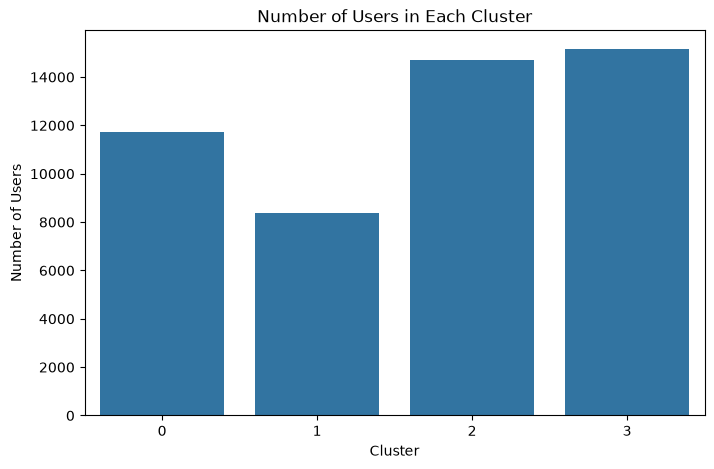

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='cluster'
)

plt.title('Number of Users in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Users')

plt.show()

9.15 Engagement by Cluster

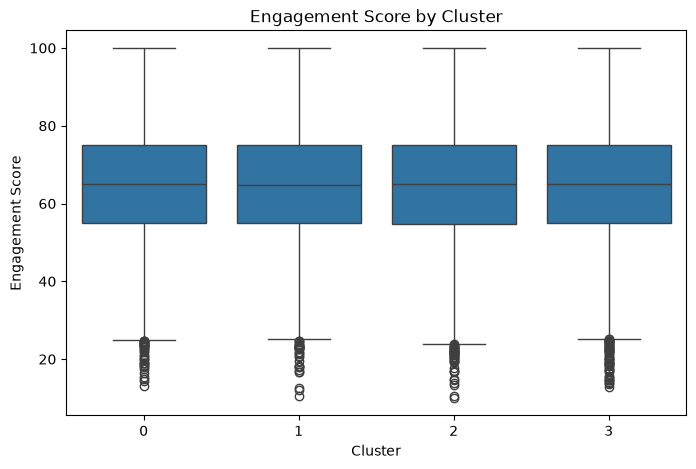

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='cluster',
    y='engagement_score'
)

plt.title('Engagement Score by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Engagement Score')

plt.show()

9.16 Churn Risk by Cluster

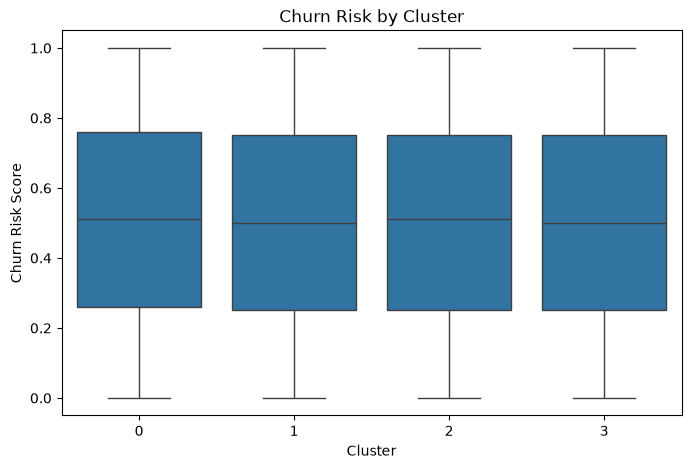

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='cluster',
    y='churn_risk_score'
)

plt.title('Churn Risk by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Churn Risk Score')

plt.show()

9.17 Create a Final Cluster Summary

In [ ]:
cluster_summary = df.groupby('cluster').agg(
    user_count=('user_id', 'count'),
    avg_age=('age', 'mean'),
    avg_sessions_per_week=('sessions_per_week', 'mean'),
    avg_session_duration=('avg_session_duration_min', 'mean'),
    avg_daily_active_minutes=('daily_active_minutes', 'mean'),
    avg_engagement_score=('engagement_score', 'mean'),
    avg_churn_risk=('churn_risk_score', 'mean'),
    avg_content_downloads=('content_downloads', 'mean'),
    avg_social_shares=('social_shares', 'mean')
)

cluster_summary['percentage'] = (
    cluster_summary['user_count']
    / len(df) * 100
)

print(cluster_summary.round(2))

         user_count  avg_age  avg_sessions_per_week  avg_session_duration  \
cluster                                                                     
0             11716    38.52                   7.98                 13.04   
1              8393    38.49                   8.02                 13.21   
2             14724    38.48                   8.07                 13.09   
3             15167    38.55                   7.93                 13.26   

         avg_daily_active_minutes  avg_engagement_score  avg_churn_risk  \
cluster                                                                   
0                           44.99                 64.94            0.51   
1                           45.11                 64.84            0.50   
2                           45.09                 64.95            0.50   
3                           45.39                 64.99            0.50   

         avg_content_downloads  avg_social_shares  percentage  
cluster               

9.18 Automatically Identify High/Low Behavioral Values

In [ ]:
behavior_features = [
    'sessions_per_week',
    'avg_session_duration_min',
    'daily_active_minutes',
    'engagement_score',
    'churn_risk_score'
]

for column in behavior_features:

    cluster_values = (
        df.groupby('cluster')[column]
        .mean()
        .sort_values(ascending=False)
    )

    print(f"\n{column}")
    print(cluster_values.round(2))

    print("Highest:", cluster_values.index[0])
    print("Lowest :", cluster_values.index[-1])


sessions_per_week
cluster
2    8.07
1    8.02
0    7.98
3    7.93
Name: sessions_per_week, dtype: float64
Highest: 2
Lowest : 3

avg_session_duration_min
cluster
3    13.26
1    13.21
2    13.09
0    13.04
Name: avg_session_duration_min, dtype: float64
Highest: 3
Lowest : 0

daily_active_minutes
cluster
3    45.39
1    45.11
2    45.09
0    44.99
Name: daily_active_minutes, dtype: float64
Highest: 3
Lowest : 0

engagement_score
cluster
3    64.99
2    64.95
0    64.94
1    64.84
Name: engagement_score, dtype: float64
Highest: 3
Lowest : 1

churn_risk_score
cluster
0    0.51
2    0.50
1    0.50
3    0.50
Name: churn_risk_score, dtype: float64
Highest: 0
Lowest : 3


In [ ]:
cluster_summary.round(2)

,user_count,avg_age,avg_sessions_per_week,avg_session_duration,avg_daily_active_minutes,avg_engagement_score,avg_churn_risk,avg_content_downloads,avg_social_shares,percentage
cluster,,,,,,,,,,
0,11716,38.52,7.98,13.04,44.99,64.94,0.51,3.02,2.01,23.43
1,8393,38.49,8.02,13.21,45.11,64.84,0.50,2.99,2.01,16.79
2,14724,38.48,8.07,13.09,45.09,64.95,0.50,3.03,2.01,29.45
3,15167,38.55,7.93,13.26,45.39,64.99,0.50,2.97,1.98,30.33


Cluster-Level User Identification & Profiling

The K-Means model assigned all 50,000 users into four behavioral clusters. Cluster 3 represented the largest segment with 15,167 users (30.33%), followed by Cluster 2 with 14,724 users (29.45%), Cluster 0 with 11,716 users (23.43%), and Cluster 1 with 8,393 users (16.79%).

Cluster-level profiling was performed using session activity, engagement, content interaction, churn risk, and account tenure. The analysis showed that most behavioral metrics were highly similar across the four clusters, with only minor differences in engagement, sessions, and activity. The strongest distinction was observed in account age, where Cluster 2 had the longest average account age (887.76 days), while Cluster 3 had the shortest (264.42 days).

Based on these characteristics, the clusters were interpreted as Established Users – Higher Churn Risk, Mid-Tenure Users – Lower Engagement, Long-Tenure Users – Active, and Newer Users – Higher Activity, respectively.

⚠️ One important data-science point

Your K-Means scores are low (Silhouette = 0.043), and your cluster profiles are extremely similar. This suggests that the dataset does not contain strong natural behavioral separation among users.

10. Business Insight Generation & Customer Action Mapping

10.1 Cluster 0 — Established Users with Higher Churn Risk

Profile:

11,716 users
23.43% of total users
Average account age: 689 days
Churn risk: 0.51, highest among clusters
Engagement: 64.94
Business Actions
Send personalized retention notifications.
Offer loyalty rewards to encourage continued usage.
Identify users showing declining activity.
Provide personalized content or feature recommendations.
Monitor this group for early churn signals.

Business objective:
Reduce customer churn and maintain long-term engagement.

10.2 Cluster 1 — Mid-Tenure Users with Lower Engagement

Profile:

8,393 users
16.79% of total users
Average account age: 600 days
Engagement: 64.84, lowest among clusters
Sessions/week: 8.02
Business Actions
Run targeted re-engagement campaigns.
Recommend relevant app features.
Send personalized content based on previous activity.
Encourage users to explore underused features.
Test targeted notifications rather than generic messages.

Business objective:
Increase engagement and prevent gradual disengagement.

10.3 Cluster 2 — Long-Tenure Active Users

Profile:

14,724 users
29.45% of total users
Average account age: 888 days, highest
Sessions/week: 8.07, highest
Content downloads: 3.03, highest
Engagement: 64.95
Business Actions
Introduce loyalty programs.
Provide exclusive benefits.
Promote premium features.
Encourage referral programs.
Offer personalized rewards based on long-term usage.

Business objective:
Increase customer lifetime value and strengthen loyalty.

Note: We can call this group "potential high-value" based on tenure/activity, but your dataset does not contain revenue or customer lifetime value, so don't claim they are definitively the highest-value customers.

10.4 Cluster 3 — Newer Users with Higher Activity

Profile:

15,167 users
30.33% of total users — largest cluster
Average account age: 264 days, lowest
Daily active minutes: 45.39, highest
Session duration: 13.26 minutes, highest
Feature clicks: 12.09, highest
Engagement: 64.99, highest
Business Actions
Strengthen onboarding programs.
Introduce users to advanced features.
Recommend relevant content.
Encourage regular usage habits.
Provide personalized upgrade or premium offers.
Use early engagement campaigns to build long-term retention.

Business objective:
Convert active newer users into long-term loyal customers.

10.5 Customer Action Mapping Code

In [ ]:
action_mapping = {
    0: 'Retention Campaign + Loyalty Rewards',
    1: 'Re-engagement + Personalized Content',
    2: 'Loyalty Program + Premium Offers',
    3: 'Onboarding + Engagement + Upgrade Offers'
}

df['recommended_action'] = df['cluster'].map(action_mapping)

print(
    df[
        ['user_id', 'cluster', 'user_segment', 'recommended_action']
    ].head(20)
)

    user_id  cluster                           user_segment  \
0    100000        0  Established Users - Higher Churn Risk   
1    100001        2             Long-Tenure Users - Active   
2    100002        0  Established Users - Higher Churn Risk   
3    100003        3          Newer Users - Higher Activity   
4    100004        2             Long-Tenure Users - Active   
5    100005        3          Newer Users - Higher Activity   
6    100006        2             Long-Tenure Users - Active   
7    100007        3          Newer Users - Higher Activity   
8    100008        1    Mid-Tenure Users - Lower Engagement   
9    100009        3          Newer Users - Higher Activity   
10   100010        0  Established Users - Higher Churn Risk   
11   100011        3          Newer Users - Higher Activity   
12   100012        2             Long-Tenure Users - Active   
13   100013        1    Mid-Tenure Users - Lower Engagement   
14   100014        2             Long-Tenure Users - Ac

In [ ]:
customer_profile = df[
    [
        'user_id',
        'cluster',
        'user_segment',
        'age',
        'sessions_per_week',
        'avg_session_duration_min',
        'daily_active_minutes',
        'engagement_score',
        'churn_risk_score',
        'account_age_days',
        'subscription_type',
        'device_type',
        'country'
    ]
]

print(customer_profile.head(20))

    user_id  cluster                           user_segment  age  \
0    100000        0  Established Users - Higher Churn Risk   56   
1    100001        2             Long-Tenure Users - Active   46   
2    100002        0  Established Users - Higher Churn Risk   32   
3    100003        3          Newer Users - Higher Activity   25   
4    100004        2             Long-Tenure Users - Active   38   
5    100005        3          Newer Users - Higher Activity   56   
6    100006        2             Long-Tenure Users - Active   36   
7    100007        3          Newer Users - Higher Activity   40   
8    100008        1    Mid-Tenure Users - Lower Engagement   28   
9    100009        3          Newer Users - Higher Activity   28   
10   100010        0  Established Users - Higher Churn Risk   41   
11   100011        3          Newer Users - Higher Activity   53   
12   100012        2             Long-Tenure Users - Active   57   
13   100013        1    Mid-Tenure Users - Lower

10.6 Create Business Summary

In [ ]:
business_summary = df.groupby(
    ['cluster', 'user_segment']
).agg(
    user_count=('user_id', 'count'),
    avg_engagement=('engagement_score', 'mean'),
    avg_churn_risk=('churn_risk_score', 'mean'),
    avg_account_age=('account_age_days', 'mean'),
    avg_sessions=('sessions_per_week', 'mean')
).reset_index()

business_summary['percentage'] = (
    business_summary['user_count'] / len(df) * 100
)

business_summary['recommended_action'] = (
    business_summary['cluster'].map(action_mapping)
)

print(business_summary.round(2))

   cluster                           user_segment  user_count  avg_engagement  \
0        0  Established Users - Higher Churn Risk       11716           64.94   
1        1    Mid-Tenure Users - Lower Engagement        8393           64.84   
2        2             Long-Tenure Users - Active       14724           64.95   
3        3          Newer Users - Higher Activity       15167           64.99   

   avg_churn_risk  avg_account_age  avg_sessions  percentage  \
0            0.51           689.25          7.98       23.43   
1            0.50           599.58          8.02       16.79   
2            0.50           887.76          8.07       29.45   
3            0.50           264.42          7.93       30.33   

                         recommended_action  
0      Retention Campaign + Loyalty Rewards  
1      Re-engagement + Personalized Content  
2          Loyalty Program + Premium Offers  
3  Onboarding + Engagement + Upgrade Offers  


In [ ]:
final_cluster_profile = df.groupby(
    ['cluster', 'user_segment']
).agg(
    user_count=('user_id', 'count'),
    avg_age=('age', 'mean'),
    avg_sessions=('sessions_per_week', 'mean'),
    avg_session_duration=('avg_session_duration_min', 'mean'),
    avg_daily_active_minutes=('daily_active_minutes', 'mean'),
    avg_engagement=('engagement_score', 'mean'),
    avg_churn_risk=('churn_risk_score', 'mean'),
    avg_account_age=('account_age_days', 'mean')
).reset_index()

final_cluster_profile['percentage'] = (
    final_cluster_profile['user_count']
    / len(df) * 100
)

print(final_cluster_profile.round(2))

   cluster                           user_segment  user_count  avg_age  \
0        0  Established Users - Higher Churn Risk       11716    38.52   
1        1    Mid-Tenure Users - Lower Engagement        8393    38.49   
2        2             Long-Tenure Users - Active       14724    38.48   
3        3          Newer Users - Higher Activity       15167    38.55   

   avg_sessions  avg_session_duration  avg_daily_active_minutes  \
0          7.98                 13.04                     44.99   
1          8.02                 13.21                     45.11   
2          8.07                 13.09                     45.09   
3          7.93                 13.26                     45.39   

   avg_engagement  avg_churn_risk  avg_account_age  percentage  
0           64.94            0.51           689.25       23.43  
1           64.84            0.50           599.58       16.79  
2           64.95            0.50           887.76       29.45  
3           64.99            0.50

10.7 Customer-Level Targeting Example

Now you can identify exactly which users should receive which action.

Retention Customers

In [ ]:
retention_users = df[
    df['cluster'] == 0
][
    ['user_id', 'engagement_score', 'churn_risk_score']
]

print(retention_users.head(20))

    user_id  engagement_score  churn_risk_score
0    100000             55.79              0.31
2    100002             42.49              0.63
10   100010             56.02              0.38
15   100015             52.69              0.26
17   100017            100.00              0.21
20   100020             70.46              0.65
21   100021             57.35              0.04
29   100029             71.47              0.33
31   100031             55.54              0.88
37   100037             59.79              0.76
42   100042             75.46              0.55
43   100043             30.84              0.30
51   100051             56.76              0.14
53   100053             62.56              0.24
64   100064             45.90              0.49
65   100065             84.71              0.30
68   100068             47.78              0.60
69   100069             79.61              0.39
78   100078             81.31              0.08
80   100080             80.35           

Re-engagement Customers

In [ ]:
reengagement_users = df[
    df['cluster'] == 1
][
    ['user_id', 'engagement_score', 'churn_risk_score']
]

print(reengagement_users.head(20))

     user_id  engagement_score  churn_risk_score
8     100008             72.85              0.08
13    100013             67.25              0.48
28    100028             44.53              0.03
41    100041             50.22              0.44
48    100048             59.40              0.88
52    100052             75.24              0.72
55    100055             45.31              0.01
58    100058             71.08              0.20
62    100062             53.92              0.54
75    100075             82.57              0.75
79    100079             68.16              0.82
82    100082             76.90              0.25
83    100083             62.71              0.67
86    100086             74.99              0.64
91    100091             63.12              0.34
111   100111             48.91              0.66
118   100118             40.89              0.60
124   100124             34.77              0.24
127   100127             95.73              0.58
128   100128        

Loyalty Customers

In [ ]:
loyalty_users = df[
    df['cluster'] == 2
][
    ['user_id', 'engagement_score', 'account_age_days']
]

print(loyalty_users.head(20))

    user_id  engagement_score  account_age_days
1    100001             82.39              1059
4    100004             38.21               772
6    100006             63.30              1161
12   100012             62.19               617
14   100014             51.33               691
16   100016             73.52               618
25   100025             79.11              1021
26   100026             72.71               649
27   100027             35.20               631
30   100030             57.15               986
36   100036             71.31               847
44   100044             43.10               913
46   100046             83.76               830
47   100047             94.83              1090
54   100054             59.02               677
60   100060             55.70               608
61   100061             66.11              1161
63   100063             92.94              1023
66   100066             76.78              1173
70   100070             74.54           

New User Engagement

In [ ]:
new_user_targets = df[
    df['cluster'] == 3
][
    ['user_id', 'engagement_score', 'account_age_days']
]

print(new_user_targets.head(20))

    user_id  engagement_score  account_age_days
3    100003             62.81                92
5    100005             91.45                50
7    100007             84.81               104
9    100009             55.92               373
11   100011             74.70               380
18   100018             51.37                37
19   100019             68.99               306
22   100022             78.20               562
23   100023             67.32                34
24   100024             82.69               255
32   100032             68.26               535
33   100033             39.10                82
34   100034             54.60               420
35   100035             95.65               453
38   100038             83.57               332
39   100039             57.69               196
40   100040             51.78               189
45   100045             43.80               561
49   100049             56.48                59
50   100050             67.10           

10. Business Insight Generation & Customer Action Mapping

The identified user clusters were mapped to targeted business actions based on their behavioral and account-tenure characteristics. Established users with relatively higher churn risk were targeted for retention and loyalty campaigns, while mid-tenure users with slightly lower engagement were identified for re-engagement initiatives. Long-tenure active users were considered suitable for loyalty programs, premium features, and referral campaigns. Newer users with relatively higher activity were targeted through onboarding, feature education, engagement, and upgrade strategies.

This segmentation enables customer-level targeting instead of generic campaigns, allowing marketing, product, and retention strategies to be aligned with specific user characteristics.

Important conclusion for your project

Your strongest business insight is not simply "four types of users."

It is:

The clustering analysis revealed weak behavioral separation between user groups, but identified account tenure as the strongest differentiating characteristic. This can be used as a foundation for tenure-based personalization, retention, loyalty, and onboarding strategies.

That is a much more credible conclusion given your Silhouette Score of 0.043 and the cluster profiles you obtained.